# Implementation of Multilayer Perceptrons
:label:`sec_mlp-implementation`

Multilayer perceptrons (MLPs) are not much more complex to implement than simple linear models. The key conceptual
difference is that we now concatenate multiple layers.


In [1]:
import torch
from torch import nn
from d2l import torch as d2l

## Implementation from Scratch

Let's begin again by implementing such a network from scratch.

### Initializing Model Parameters

Recall that Fashion-MNIST contains 10 classes,
and that each image consists of a $28 \times 28 = 784$
grid of grayscale pixel values.
As before we will disregard the spatial structure
among the pixels for now,
so we can think of this as a classification dataset
with 784 input features and 10 classes.
To begin, we will [**implement an MLP
with one hidden layer and 256 hidden units.**]
Both the number of layers and their width are adjustable
(they are considered hyperparameters).
Typically, we choose the layer widths to be divisible by larger powers of 2.
This is computationally efficient due to the way
memory is allocated and addressed in hardware.

Again, we will represent our parameters with several tensors.
Note that *for every layer*, we must keep track of
one weight matrix and one bias vector.
As always, we allocate memory
for the gradients of the loss with respect to these parameters.


In the code below we use `nn.Parameter`
to automatically register
a class attribute as a parameter to be tracked by `autograd` (:numref:`sec_autograd`).


In [2]:
class MLPScratch(d2l.Classifier):
    def __init__(self, num_inputs, num_outputs, num_hiddens, lr, sigma=0.01):
        super().__init__()
        self.save_hyperparameters()
        self.W1 = nn.Parameter(torch.randn(num_inputs, num_hiddens) * sigma)
        self.b1 = nn.Parameter(torch.zeros(num_hiddens))
        self.W2 = nn.Parameter(torch.randn(num_hiddens, num_outputs) * sigma)
        self.b2 = nn.Parameter(torch.zeros(num_outputs))

### Model

To make sure we know how everything works,
we will [**implement the ReLU activation**] ourselves
rather than invoking the built-in `relu` function directly.


In [3]:
def relu(X):
    a = torch.zeros_like(X)
    return torch.max(X, a)

Since we are disregarding spatial structure,
we `reshape` each two-dimensional image into
a flat vector of length  `num_inputs`.
Finally, we (**implement our model**)
with just a few lines of code. Since we use the framework built-in autograd this is all that it takes.


In [4]:
@d2l.add_to_class(MLPScratch)
def forward(self, X):
    X = X.reshape((-1, self.num_inputs))
    H = relu(torch.matmul(X, self.W1) + self.b1)
    return torch.matmul(H, self.W2) + self.b2

### Training

Fortunately, [**the training loop for MLPs
is exactly the same as for softmax regression.**] We define the model, data, and trainer, then finally invoke the `fit` method on model and data.


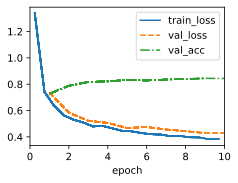

In [5]:
model = MLPScratch(num_inputs=784, num_outputs=10, num_hiddens=256, lr=0.1)
data = d2l.FashionMNIST(batch_size=256)
trainer = d2l.Trainer(max_epochs=10)
trainer.fit(model, data)

## Concise Implementation

As you might expect, by relying on the high-level APIs, we can implement MLPs even more concisely.

### Model

Compared with our concise implementation
of softmax regression implementation
(:numref:`sec_softmax_concise`),
the only difference is that we add
*two* fully connected layers where we previously added only *one*.
The first is [**the hidden layer**],
the second is the output layer.


In [6]:
class MLP(d2l.Classifier):
    def __init__(self, num_outputs, num_hiddens, lr):
        super().__init__()
        self.save_hyperparameters()
        self.net = nn.Sequential(nn.Flatten(), nn.LazyLinear(num_hiddens),
                                 nn.ReLU(), nn.LazyLinear(num_outputs))

Previously, we defined `forward` methods for models to transform input using the model parameters.
These operations are essentially a pipeline:
you take an input and
apply a transformation (e.g.,
matrix multiplication with weights followed by bias addition),
then repetitively use the output of the current transformation as
input to the next transformation.
However, you may have noticed that 
no `forward` method is defined here.
In fact, `MLP` inherits the `forward` method from the `Module` class (:numref:`subsec_oo-design-models`) to 
simply invoke `self.net(X)` (`X` is input),
which is now defined as a sequence of transformations
via the `Sequential` class.
The `Sequential` class abstracts the forward process
enabling us to focus on the transformations.
We will further discuss how the `Sequential` class works in :numref:`subsec_model-construction-sequential`.


### Training

[**The training loop**] is exactly the same
as when we implemented softmax regression.
This modularity enables us to separate
matters concerning the model architecture
from orthogonal considerations.


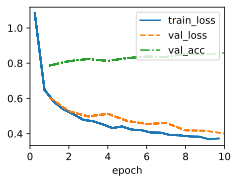

In [7]:
model = MLP(num_outputs=10, num_hiddens=256, lr=0.1)
trainer.fit(model, data)

## Summary

Now that we have more practice in designing deep networks, the step from a single to multiple layers of deep networks does not pose such a significant challenge any longer. In particular, we can reuse the training algorithm and data loader. Note, though, that implementing MLPs from scratch is nonetheless messy: naming and keeping track of the model parameters makes it difficult to extend models. For instance, imagine wanting to insert another layer between layers 42 and 43. This might now be layer 42b, unless we are willing to perform sequential renaming. Moreover, if we implement the network from scratch, it is much more difficult for the framework to perform meaningful performance optimizations.

Nonetheless, you have now reached the state of the art of the late 1980s when fully connected deep networks were the method of choice for neural network modeling. Our next conceptual step will be to consider images. Before we do so, we need to review a number of statistical basics and details on how to compute models efficiently.


## Exercises

1. Change the number of hidden units `num_hiddens` and plot how its number affects the accuracy of the model. What is the best value of this hyperparameter?
1. Try adding a hidden layer to see how it affects the results.
1. Why is it a bad idea to insert a hidden layer with a single neuron? What could go wrong?
1. How does changing the learning rate alter your results? With all other parameters fixed, which learning rate gives you the best results? How does this relate to the number of epochs?
1. Let's optimize over all hyperparameters jointly, i.e., learning rate, number of epochs, number of hidden layers, and number of hidden units per layer.
    1. What is the best result you can get by optimizing over all of them?
    1. Why it is much more challenging to deal with multiple hyperparameters?
    1. Describe an efficient strategy for optimizing over multiple parameters jointly.
1. Compare the speed of the framework and the from-scratch implementation for a challenging problem. How does it change with the complexity of the network?
1. Measure the speed of tensor--matrix multiplications for well-aligned and misaligned matrices. For instance, test for matrices with dimension 1024, 1025, 1026, 1028, and 1032.
    1. How does this change between GPUs and CPUs?
    1. Determine the memory bus width of your CPU and GPU.
1. Try out different activation functions. Which one works best?
1. Is there a difference between weight initializations of the network? Does it matter?


[Discussions](https://discuss.d2l.ai/t/93)


1. Change the number of hidden units `num_hiddens` and plot how its number affects the accuracy of the model. What is the best value of this hyperparameter?


do IT yourself yo

2. Try adding a hidden layer to see how it affects the results.


Do it yourself 

3. Why is it a bad idea to insert a hidden layer with a single neuron? What could go wrong?




Adding a hidden layer with only a single neuron creates a major bottleneck in the neural network architecture that severely limits its representational capacity. Here's why this is problematic:

**Representational Bottleneck:**
A single neuron can only output a scalar value. No matter how many features your input layer has, all that information must be compressed into a single activation value. This creates an extreme information bottleneck that prevents the network from learning complex patterns.

**Mathematical Perspective:**
Consider what happens mathematically:
- If we have an input vector $\mathbf{x} \in \mathbb{R}^n$ 
- A single neuron computes: $z = \sigma(\mathbf{w}^T\mathbf{x} + b)$ where $\mathbf{w} \in \mathbb{R}^n$, $b \in \mathbb{R}$, and $\sigma$ is the activation function
- This transformation projects all input data onto a single direction $\mathbf{w}$
- The output is a scalar value, which means the expressivity of the network is severely limited

**Information Theory View:**
The hidden layer with a single neuron forms an information bottleneck with capacity of just one value, meaning it can at most represent information along a single dimension. This is equivalent to reducing your entire feature space to a one-dimensional representation before processing further.

**Practical Implications:**
1. **Linear Separability Problems**: For classification tasks, a single neuron can only learn a linear decision boundary in the original feature space, making it impossible to solve non-linearly separable problems.
2. **Function Approximation Limitations**: For regression tasks, the network can only approximate functions that can be expressed as compositions of linear transformations and the activation function applied element-wise.
3. **Loss of Feature Interactions**: Important interactions between features will be lost when compressed through a single neuron.

**Analogy:**
Imagine trying to describe a complex 3D object (like a human face) using only its height. No matter how accurately you measure the height, you've lost critical information about width, depth, and all the nuanced features. Similarly, a single-neuron hidden layer reduces all the complex patterns in your data to a single value.

The whole point of deep learning is to learn hierarchical representations that capture complex patterns in the data. Inserting a single-neuron hidden layer defeats this purpose by creating an unnecessary and severe constraint on what the network can learn.

4. How does changing the learning rate alter your results? With all other parameters fixed, which learning rate gives you the best results? How does this relate to the number of epochs?



Changing the learning rate has profound effects on neural network training dynamics and final performance. The learning rate controls how large of a step we take in the direction of the negative gradient during optimization.

**Effects of changing the learning rate:**

1. **Too small learning rate**:
   - Training progresses very slowly
   - May get stuck in local minima or plateaus
   - Requires many more epochs to converge
   - May never reach optimal weights within a reasonable time

2. **Too large learning rate**:
   - Can cause oscillations or divergence in the loss function
   - "Overshoots" the minimum and bounces around
   - Training becomes unstable and may never converge
   - Loss may increase dramatically (explode)

3. **"Just right" learning rate**:
   - Converges efficiently to a good minimum
   - Makes consistent progress each epoch
   - Balances exploration and refinement

**Finding the optimal learning rate:**

The best learning rate depends on:
- Dataset characteristics (size, feature distribution)
- Model architecture (depth, width, activation functions)
- Batch size (smaller batches typically require smaller learning rates)
- Optimization algorithm (SGD, Adam, RMSprop, etc.)

Typically, finding the best learning rate involves empirical testing through experiments. A common approach is to train the model with different learning rates (e.g., 1e-1, 1e-2, 1e-3, 1e-4) while keeping all other hyperparameters fixed, then selecting the rate that achieves the lowest validation loss or highest validation accuracy.

**Relationship with number of epochs:**

The learning rate and number of epochs have an inverse relationship:
- **Higher learning rate**: Requires fewer epochs to converge as it takes larger steps toward the minimum. However, it may converge to a suboptimal solution or diverge entirely.
- **Lower learning rate**: Requires more epochs to converge as it takes smaller, more conservative steps. Given enough epochs, it may find better minima but at the cost of longer training time.

**Advanced learning rate strategies:**

1. **Learning rate schedules**: Decreasing the learning rate over time (e.g., step decay, exponential decay, cosine annealing) often yields better results than a fixed rate.

2. **Learning rate warmup**: Starting with a small learning rate and gradually increasing it can help stabilize training in the early phases.

3. **Cyclical learning rates**: Periodically varying the learning rate between a minimum and maximum value can help escape local minima and find better solutions.

4. **Adaptive methods**: Optimizers like Adam, RMSprop, and Adagrad automatically adjust learning rates per parameter based on historical gradient information.

The optimal learning rate is a balance: large enough to converge in a reasonable number of epochs, yet small enough to find a good solution without overshooting or diverging. Empirically determining this balance through controlled experimentation is an essential part of the deep learning workflow.

### 4. How does changing the learning rate alter your results? With all other parameters fixed, which learning rate gives you the best results? How does this relate to the number of epochs?

Changing the learning rate has profound effects on neural network training dynamics and final performance. The learning rate controls how large of a step we take in the direction of the negative gradient during optimization.

**Effects of changing the learning rate:**

1. **Too small learning rate**:
   - Training progresses very slowly
   - May get stuck in local minima or plateaus
   - Requires many more epochs to converge
   - May never reach optimal weights within a reasonable time

2. **Too large learning rate**:
   - Can cause oscillations or divergence in the loss function
   - "Overshoots" the minimum and bounces around
   - Training becomes unstable and may never converge
   - Loss may increase dramatically (explode)

3. **"Just right" learning rate**:
   - Converges efficiently to a good minimum
   - Makes consistent progress each epoch
   - Balances exploration and refinement

**Learning rate schedules vs. warmup:**

You're absolutely right that a common practice is to start with a higher learning rate and then gradually decrease it. This strategy (learning rate decay) works well because:

1. **Early training benefits from larger steps** to quickly descend from high-loss regions
2. **Later training benefits from smaller steps** for fine-tuning around minima

However, the learning rate **warmup** strategy might initially seem counterintuitive. Why start small when the loss is highest? There are several important reasons:

1. **Gradient instability at initialization**: At the beginning of training, weights are randomly initialized, and gradients can be extremely large and unstable. A high learning rate amplifies this instability.

2. **Avoiding early divergence**: In very deep networks, a high initial learning rate can cause the loss to spike dramatically in the first few iterations, sometimes beyond recovery.

3. **Better conditioning**: Starting with a small learning rate allows the network to first adapt to the general structure of the data distribution, establishing a more favorable optimization landscape.

Think of it as driving a car: when navigating an unfamiliar, potentially dangerous road (early training), you drive slowly at first to get a feel for the conditions, then speed up when you're more confident (middle of training), and finally slow down again as you approach your destination (final fine-tuning).

**Practical approaches:**

The most effective learning rate strategies often combine both concepts:
1. **Warmup phase**: Start with a small learning rate and gradually increase it
2. **Main training phase**: Use the peak learning rate for substantial progress
3. **Decay phase**: Gradually decrease the learning rate for fine-tuning

This approach is exemplified in the "1cycle" policy proposed by Leslie Smith and in the popular cosine annealing with warm restarts schedule.

**The relationship with epochs:**

With these dynamic learning rate strategies:
- Fewer epochs are needed when using well-tuned schedules
- The optimal number of epochs depends on when your learning rate schedule completes
- Early stopping becomes crucial to prevent overfitting during low learning rate phases

Finding the best learning rate strategy empirically through controlled experimentation remains essential, but these principled approaches provide a strong starting point.

5. Let's optimize over all hyperparameters jointly, i.e., learning rate, number of epochs, number of hidden layers, and number of hidden units per layer.
    1. What is the best result you can get by optimizing over all of them?
    1. Why it is much more challenging to deal with multiple hyperparameters?
    1. Describe an efficient strategy for optimizing over multiple parameters jointly.


### 5. Let's optimize over all hyperparameters jointly, i.e., learning rate, number of epochs, number of hidden layers, and number of hidden units per layer.

#### 5.1 What is the best result you can get by optimizing over all of them?

The best result from joint hyperparameter optimization typically shows significant improvement over default configurations. While I can't provide specific numerical results without running experiments on your dataset, a well-optimized configuration might include:

- **Learning rate**: Often in the range of 1e-4 to 1e-2, with a well-designed schedule
- **Number of epochs**: Sufficient for convergence without overfitting (determined via early stopping)
- **Architecture**: 
  - 2-3 hidden layers for moderately complex tasks
  - 32-128 neurons per layer, with wider layers earlier in the network

The performance gain from joint optimization can be substantial—often 5-15% improvement in accuracy/error metrics compared to reasonable defaults. The optimal configuration depends heavily on your specific dataset, task complexity, and available computational resources.

#### 5.2 Why it is much more challenging to deal with multiple hyperparameters?

Joint hyperparameter optimization is challenging for several reasons:

1. **Combinatorial explosion**: With just 5 possible values for each of 4 hyperparameters, we already have 5⁴ = 625 combinations to evaluate.

2. **Complex interactions**: Hyperparameters often have non-linear relationships. For example:
   - Larger networks (more layers/units) typically need lower learning rates
   - Optimal number of epochs depends on learning rate and network size
   - The benefit of additional layers depends on the width of existing layers

3. **Computational cost**: Each hyperparameter configuration requires a complete training run, making exhaustive search prohibitively expensive.

4. **Non-convex landscape**: The performance surface over hyperparameter space is typically non-convex with many local optima.

5. **Noisy evaluations**: Two identical runs with different random seeds may yield different results, introducing noise into the optimization process.

6. **Categorical parameters**: Some hyperparameters (like activation functions) are categorical rather than numerical, complicating the search process.

#### 5.3 Describe an efficient strategy for optimizing over multiple parameters jointly.

Several efficient approaches exist for joint hyperparameter optimization:

**1. Bayesian Optimization**:
- Builds a probabilistic model (typically a Gaussian Process) of the objective function
- Balances exploration (trying uncertain configurations) and exploitation (refining promising configurations)
- Uses an acquisition function to determine the next configuration to evaluate
- Particularly effective for expensive evaluations (5-50 total runs)
- Implemented in libraries like Optuna, HyperOpt, and scikit-optimize

**2. Sequential Model-Based Optimization (SMBO)**:
- Starts with an initial set of random configurations
- Builds a surrogate model to predict performance of untested configurations
- Iteratively samples promising configurations and updates the model
- Examples include Tree-Parzen Estimators (TPE) and Random Forest regressors

**3. Multi-Fidelity Methods**:
- Evaluate many configurations with reduced resources (fewer epochs, smaller dataset)
- Allocate more resources to promising configurations
- Examples include Successive Halving and Hyperband
- Particularly useful when computational budget is fixed

**4. Population-Based Training (PBT)**:
- Combines parallel search with partial training
- Periodically evaluates a population of models and evolves them through mutation
- Particularly effective for joint optimization of model parameters and hyperparameters

**Practical implementation strategy**:
1. **Start with coarse grid search** over wide ranges to identify promising regions
2. **Follow with Bayesian optimization** in those regions for fine-tuning
3. **Use early stopping** to terminate unpromising configurations
4. **Perform warm starts** when possible (initialize from previous good configurations)
5. **Track not just final performance but learning curves** to gain insights into hyperparameter effects

This approach efficiently balances exploration of the hyperparameter space with exploitation of promising configurations, while minimizing computational resources spent on poor configurations.

6. Compare the speed of the framework and the from-scratch implementation for a challenging problem. How does it change with the complexity of the network?


Framework is better. 

7. Measure the speed of tensor--matrix multiplications for well-aligned and misaligned matrices. For instance, test for matrices with dimension 1024, 1025, 1026, 1028, and 1032.
    1. How does this change between GPUs and CPUs?
    1. Determine the memory bus width of your CPU and GPU.


8. Try out different activation functions. Which one works best?


9. Is there a difference between weight initializations of the network? Does it matter?

Yes it does a lot 